In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn import svm
from collections import Counter

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("getanmolgupta01/internet-speed")

path = os.path.join(path, os.listdir(path)[0])
print("Path to dataset files:", path)

100%|██████████| 515k/515k [00:00<00:00, 37.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/getanmolgupta01/internet-speed/versions/1/Internet Speed.csv


In [3]:
df = pd.read_csv(path)
# print(df)

In [4]:
print('Learning DF')
print(df.columns)


Learning DF
Index(['Ping_latency', 'Download_speed', 'Upload_speed', 'Packet_loss_rate',
       'Router_distance', 'Network_congestion', 'ISP_quality',
       'Connection_type_DSL', 'Connection_type_Cable', 'Connection_type_Fiber',
       'Signal_strength', 'Weather_conditions', 'Internet_speed'],
      dtype='object')


In [5]:
print(df.iloc[0:2,:])

   Ping_latency  Download_speed  Upload_speed  Packet_loss_rate  \
0     21.854305       42.395374     19.934759          0.999340   
1     47.782144       49.976388     17.979781          1.493494   

   Router_distance  Network_congestion  ISP_quality  Connection_type_DSL  \
0         7.569985            1.369483     7.467012             0.000000   
1         2.660608            1.243015     6.215047             2.373401   

   Connection_type_Cable  Connection_type_Fiber  Signal_strength  \
0                    0.0               0.000000        76.190258   
1                    0.0               3.869607        70.945684   

   Weather_conditions  Internet_speed  
0            2.552049      730.336287  
1            2.788454      994.148168  


<Axes: xlabel='Internet_speed', ylabel='Count'>

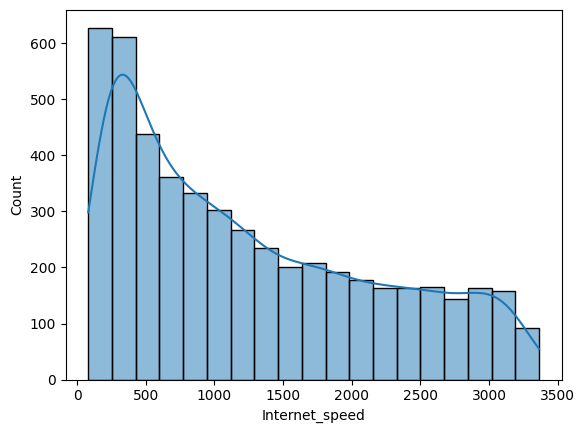

In [6]:
sns.histplot(x='Internet_speed', data=df, kde=True)

In [7]:
df

,Ping_latency,Download_speed,Upload_speed,Packet_loss_rate,Router_distance,Network_congestion,ISP_quality,Connection_type_DSL,Connection_type_Cable,Connection_type_Fiber,Signal_strength,Weather_conditions,Internet_speed
0,21.854305,42.395374,19.934759,0.999340,7.569985,1.369483,7.467012,0.000000,0.000000,0.000000,76.190258,2.552049,730.336287
1,47.782144,49.976388,17.979781,1.493494,2.660608,1.243015,6.215047,2.373401,0.000000,3.869607,70.945684,2.788454,994.148168
2,37.939727,86.182002,10.455388,1.125334,4.119757,3.416768,9.751490,1.509861,0.000000,2.332773,83.994324,3.098587,2551.867438
3,31.939632,37.300417,31.148800,0.166605,6.969526,4.864465,4.532849,0.000000,0.000000,1.608198,92.278904,4.479742,621.336539
4,12.020839,87.616720,24.877960,0.371160,5.338804,3.010885,7.114995,1.241954,0.000000,2.693502,80.535702,4.190802,2612.315499
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,45.382879,86.477319,33.242407,1.754077,3.947383,4.809102,6.040825,0.000000,3.112226,2.456354,92.054785,0.720499,2600.889238
4996,10.372146,90.263339,10.534320,0.093628,7.542697,3.991297,6.245036,0.000000,0.000000,0.000000,97.745403,1.598590,2769.740618
4997,19.752928,94.937252,4.459498,0.607397,9.309467,1.077823,6.707668,0.011109,3.744975,1.019031,97.209409,2.218448,3031.079831
4998,41.708542,42.761359,34.782156,0.886640,6.735571,2.604019,9.772978,0.000000,0.000000,3.915730,96.801547,2.196325,818.064550


In [8]:
df['Internet_speed'].describe()

,Internet_speed
count,5000.000000
mean,1257.296163
std,927.617450
min,80.606669
25%,430.808067
50%,1018.976847
75%,1951.295923
max,3364.871190


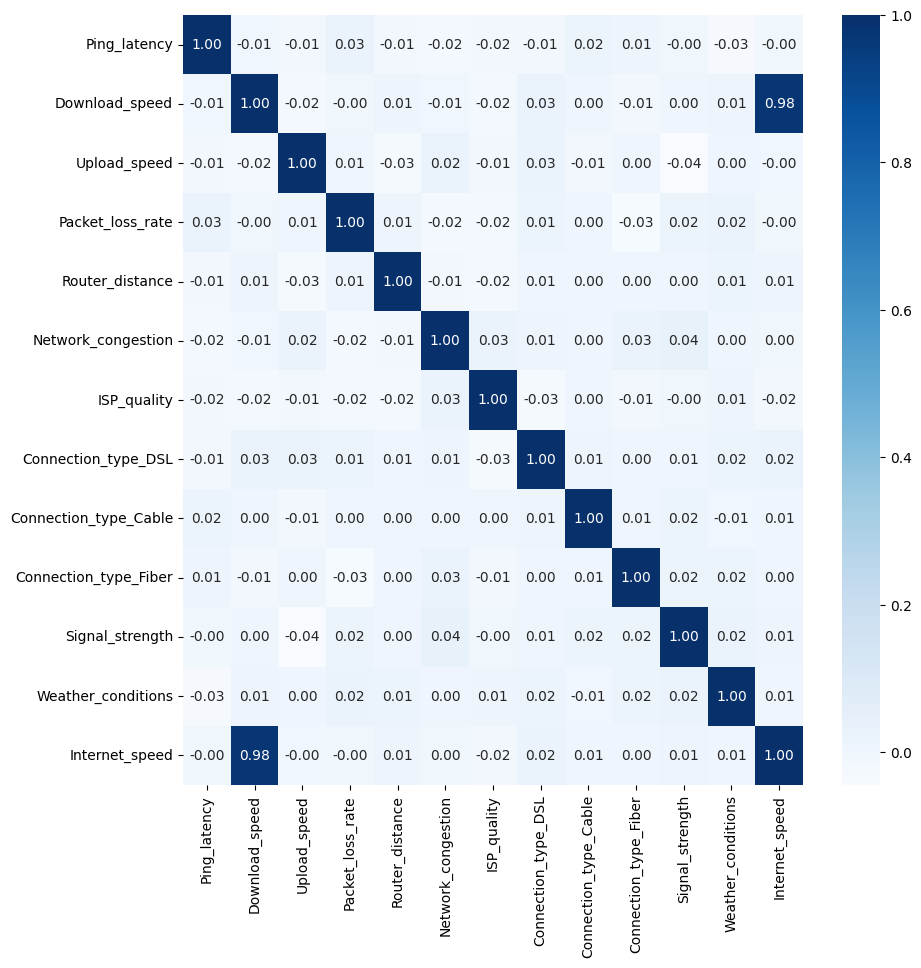

In [9]:
df_corr = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="Blues")
plt.show()

<Axes: xlabel='Weather_conditions', ylabel='Count'>

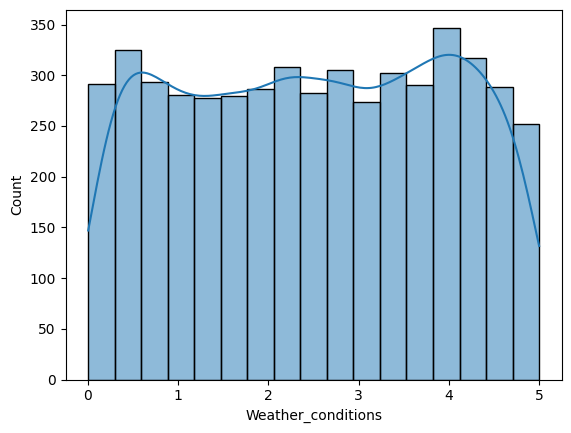

In [10]:
sns.histplot(x='Weather_conditions', kde=True, data=df)

In [11]:
df['Weather_conditions'] = df['Weather_conditions'].astype(int)

In [12]:
df['Weather_conditions'].unique()

array([2, 3, 4, 0, 1])

In [13]:
#
print(df[df['Weather_conditions'] == 4]['Internet_speed'].describe())
print(df[df['Weather_conditions'] == 3]['Internet_speed'].describe())
print(df[df['Weather_conditions'] == 2]['Internet_speed'].describe())
print(df[df['Weather_conditions'] == 1]['Internet_speed'].describe())
print(df[df['Weather_conditions'] == 0]['Internet_speed'].describe())

count     989.000000
mean     1291.954667
std       945.945522
min       111.099318
25%       456.126082
50%      1038.212874
75%      2028.456873
max      3354.763485
Name: Internet_speed, dtype: float64
count    1018.000000
mean     1237.011636
std       922.563817
min       118.761067
25%       412.637904
50%      1002.096765
75%      1888.588743
max      3329.810850
Name: Internet_speed, dtype: float64
count    1020.000000
mean     1288.008540
std       920.910380
min       109.680075
25%       479.787597
50%      1090.196366
75%      1985.256038
max      3358.105229
Name: Internet_speed, dtype: float64
count     955.000000
mean     1207.174988
std       911.989237
min        80.606669
25%       384.495029
50%       940.038900
75%      1899.090813
max      3348.374406
Name: Internet_speed, dtype: float64
count    1018.000000
mean     1260.156167
std       935.065347
min       118.387715
25%       421.685960
50%      1009.898749
75%      1976.522152
max      3364.871190
Name: Intern

In [14]:
df[df['Weather_conditions'] == 3]['Internet_speed'].describe()

,Internet_speed
count,1018.000000
mean,1237.011636
std,922.563817
min,118.761067
25%,412.637904
50%,1002.096765
75%,1888.588743
max,3329.810850


In [15]:
df[df['Weather_conditions'] == 2]['Internet_speed'].describe()

,Internet_speed
count,1020.000000
mean,1288.008540
std,920.910380
min,109.680075
25%,479.787597
50%,1090.196366
75%,1985.256038
max,3358.105229


In [16]:
df[df['Weather_conditions'] == 1]['Internet_speed'].describe()

,Internet_speed
count,955.000000
mean,1207.174988
std,911.989237
min,80.606669
25%,384.495029
50%,940.038900
75%,1899.090813
max,3348.374406


In [17]:
df[df['Weather_conditions'] == 0]['Internet_speed'].describe()

,Internet_speed
count,1018.000000
mean,1260.156167
std,935.065347
min,118.387715
25%,421.685960
50%,1009.898749
75%,1976.522152
max,3364.871190


In [18]:
print(df_corr['Internet_speed'].sort_values(ascending=False))


Internet_speed           1.000000
Download_speed           0.975699
Connection_type_DSL      0.020906
Signal_strength          0.011692
Router_distance          0.010041
Weather_conditions       0.008200
Connection_type_Cable    0.007339
Connection_type_Fiber    0.000194
Network_congestion       0.000018
Ping_latency            -0.000861
Packet_loss_rate        -0.001732
Upload_speed            -0.004202
ISP_quality             -0.015351
Name: Internet_speed, dtype: float64


In [19]:
df['Signal_strength'].describe()

,Signal_strength
count,5000.000000
mean,84.948302
std,8.609663
min,70.001406
25%,77.742714
50%,84.822169
75%,92.345908
max,99.998191


In [20]:
df = df.drop(columns=['Connection_type_DSL', 'Connection_type_Cable', 'Connection_type_Fiber'], axis=1)


In [21]:
df = df.drop(columns=['Router_distance', 'Network_congestion', 'ISP_quality'], axis=1)


In [22]:
df = df.drop(columns=['Weather_conditions'], axis=1)


In [23]:
df

,Ping_latency,Download_speed,Upload_speed,Packet_loss_rate,Signal_strength,Internet_speed
0,21.854305,42.395374,19.934759,0.999340,76.190258,730.336287
1,47.782144,49.976388,17.979781,1.493494,70.945684,994.148168
2,37.939727,86.182002,10.455388,1.125334,83.994324,2551.867438
3,31.939632,37.300417,31.148800,0.166605,92.278904,621.336539
4,12.020839,87.616720,24.877960,0.371160,80.535702,2612.315499
...,...,...,...,...,...,...
4995,45.382879,86.477319,33.242407,1.754077,92.054785,2600.889238
4996,10.372146,90.263339,10.534320,0.093628,97.745403,2769.740618
4997,19.752928,94.937252,4.459498,0.607397,97.209409,3031.079831
4998,41.708542,42.761359,34.782156,0.886640,96.801547,818.064550


In [24]:
df_corr = df.corr()
print(df_corr['Internet_speed'].sort_values(ascending=False))


Internet_speed      1.000000
Download_speed      0.975699
Signal_strength     0.011692
Ping_latency       -0.000861
Packet_loss_rate   -0.001732
Upload_speed       -0.004202
Name: Internet_speed, dtype: float64


In [25]:
df['Total_bandwidth'] = df['Download_speed'] + df['Upload_speed']
df['Upload_download_ratio'] = df['Upload_speed'] / df['Download_speed']
df['Network_efficiency'] = df['Download_speed'] / df['Ping_latency']
df['Signal_reliability'] = df['Signal_strength'] / (df['Packet_loss_rate'] + 1)

In [26]:
df

,Ping_latency,Download_speed,Upload_speed,Packet_loss_rate,Signal_strength,Internet_speed,Total_bandwidth,Upload_download_ratio,Network_efficiency,Signal_reliability
0,21.854305,42.395374,19.934759,0.999340,76.190258,730.336287,62.330134,0.470211,1.939909,38.107695
1,47.782144,49.976388,17.979781,1.493494,70.945684,994.148168,67.956168,0.359766,1.045922,28.452323
2,37.939727,86.182002,10.455388,1.125334,83.994324,2551.867438,96.637390,0.121318,2.271550,39.520537
3,31.939632,37.300417,31.148800,0.166605,92.278904,621.336539,68.449217,0.835079,1.167841,79.100373
4,12.020839,87.616720,24.877960,0.371160,80.535702,2612.315499,112.494680,0.283941,7.288736,58.735431
...,...,...,...,...,...,...,...,...,...,...
4995,45.382879,86.477319,33.242407,1.754077,92.054785,2600.889238,119.719726,0.384406,1.905505,33.424910
4996,10.372146,90.263339,10.534320,0.093628,97.745403,2769.740618,100.797660,0.116707,8.702475,89.377202
4997,19.752928,94.937252,4.459498,0.607397,97.209409,3031.079831,99.396750,0.046973,4.806237,60.476294
4998,41.708542,42.761359,34.782156,0.886640,96.801547,818.064550,77.543516,0.813402,1.025242,51.308965


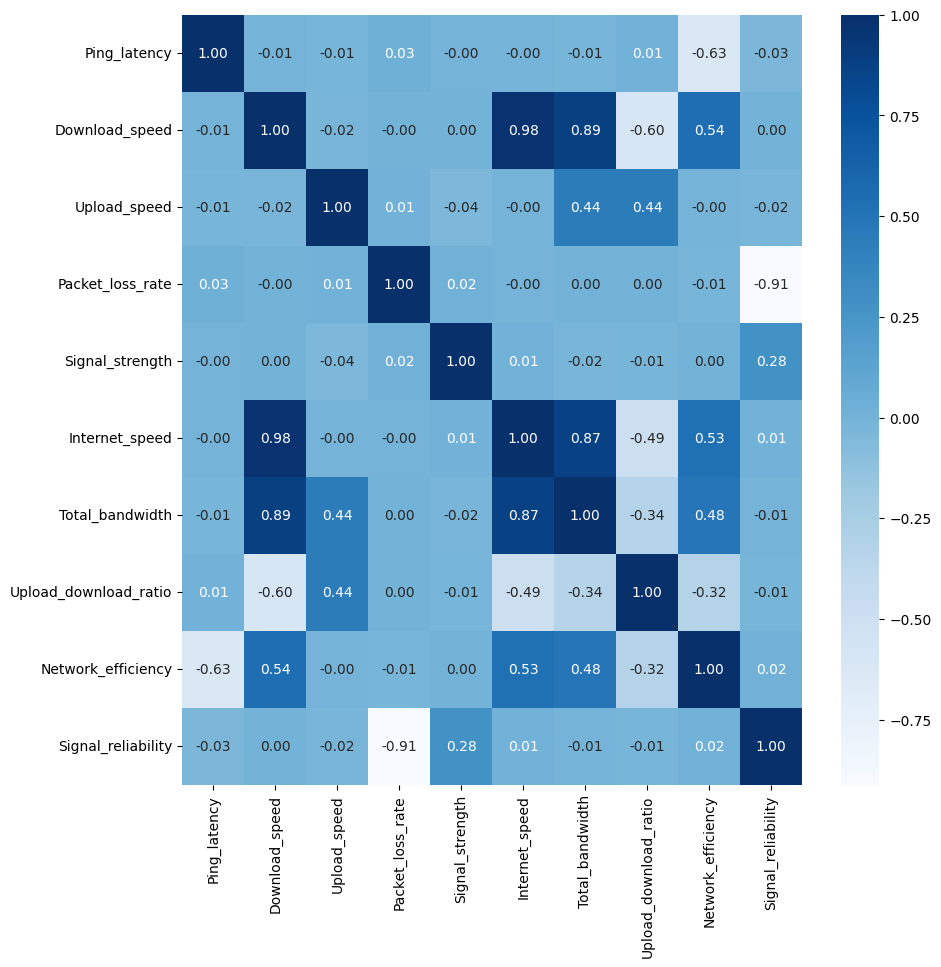

In [27]:
df_corr = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="Blues")
plt.show()

In [28]:
df_corr['Internet_speed'].sort_values(ascending=False)

,Internet_speed
Internet_speed,1.000000
Download_speed,0.975699
Total_bandwidth,0.873876
Network_efficiency,0.525194
Signal_strength,0.011692
Signal_reliability,0.008395
Ping_latency,-0.000861
Packet_loss_rate,-0.001732
Upload_speed,-0.004202
Upload_download_ratio,-0.490596


In [29]:
df

,Ping_latency,Download_speed,Upload_speed,Packet_loss_rate,Signal_strength,Internet_speed,Total_bandwidth,Upload_download_ratio,Network_efficiency,Signal_reliability
0,21.854305,42.395374,19.934759,0.999340,76.190258,730.336287,62.330134,0.470211,1.939909,38.107695
1,47.782144,49.976388,17.979781,1.493494,70.945684,994.148168,67.956168,0.359766,1.045922,28.452323
2,37.939727,86.182002,10.455388,1.125334,83.994324,2551.867438,96.637390,0.121318,2.271550,39.520537
3,31.939632,37.300417,31.148800,0.166605,92.278904,621.336539,68.449217,0.835079,1.167841,79.100373
4,12.020839,87.616720,24.877960,0.371160,80.535702,2612.315499,112.494680,0.283941,7.288736,58.735431
...,...,...,...,...,...,...,...,...,...,...
4995,45.382879,86.477319,33.242407,1.754077,92.054785,2600.889238,119.719726,0.384406,1.905505,33.424910
4996,10.372146,90.263339,10.534320,0.093628,97.745403,2769.740618,100.797660,0.116707,8.702475,89.377202
4997,19.752928,94.937252,4.459498,0.607397,97.209409,3031.079831,99.396750,0.046973,4.806237,60.476294
4998,41.708542,42.761359,34.782156,0.886640,96.801547,818.064550,77.543516,0.813402,1.025242,51.308965


In [30]:
df_copy = df.copy()

In [31]:
df.isna().sum()

,0
Ping_latency,0
Download_speed,0
Upload_speed,0
Packet_loss_rate,0
Signal_strength,0
Internet_speed,0
Total_bandwidth,0
Upload_download_ratio,0
Network_efficiency,0
Signal_reliability,0


In [32]:
X = df.drop(columns=['Internet_speed'], axis=1)
Y = df['Internet_speed']


In [33]:
print(Y.describe())

count    5000.000000
mean     1257.296163
std       927.617450
min        80.606669
25%       430.808067
50%      1018.976847
75%      1951.295923
max      3364.871190
Name: Internet_speed, dtype: float64


In [34]:
print(df.iloc[100:120, :])

     Ping_latency  Download_speed  Upload_speed  Packet_loss_rate  \
100      6.414313       47.662459     48.660608          0.931743   
101     33.638469       59.873243     31.642751          0.115367   
102     19.146019       59.236170     49.107955          0.372811   
103     27.885681       36.580536     18.212287          1.121017   
104     45.840491       34.975652     35.745522          1.732378   
105     16.218150       15.129244     12.684975          1.765611   
106     23.467232       39.845840     14.537608          0.139888   
107     38.999801       14.451994     26.571302          0.838210   
108     15.295917       77.826615     17.341670          1.166013   
109      8.464096       96.796058     10.045835          0.294140   
110     18.038815       97.157073     14.618274          1.530864   
111     12.254958       87.181754      3.715923          1.488471   
112     46.836394       62.075254     35.812334          1.806682   
113     41.365417       71.582241 

In [35]:
import pandas as pd

bins = [0, 500, 1000, 2000, 3000, float('inf')]
labels = [0, 1, 2, 3, 4]

df['Internet_class'] = pd.cut(df['Internet_speed'], bins=bins, labels=labels)

print(df[['Internet_speed', 'Internet_class']].head())


   Internet_speed Internet_class
0      730.336287              1
1      994.148168              1
2     2551.867438              3
3      621.336539              1
4     2612.315499              3


In [36]:
df

,Ping_latency,Download_speed,Upload_speed,Packet_loss_rate,Signal_strength,Internet_speed,Total_bandwidth,Upload_download_ratio,Network_efficiency,Signal_reliability,Internet_class
0,21.854305,42.395374,19.934759,0.999340,76.190258,730.336287,62.330134,0.470211,1.939909,38.107695,1
1,47.782144,49.976388,17.979781,1.493494,70.945684,994.148168,67.956168,0.359766,1.045922,28.452323,1
2,37.939727,86.182002,10.455388,1.125334,83.994324,2551.867438,96.637390,0.121318,2.271550,39.520537,3
3,31.939632,37.300417,31.148800,0.166605,92.278904,621.336539,68.449217,0.835079,1.167841,79.100373,1
4,12.020839,87.616720,24.877960,0.371160,80.535702,2612.315499,112.494680,0.283941,7.288736,58.735431,3
...,...,...,...,...,...,...,...,...,...,...,...
4995,45.382879,86.477319,33.242407,1.754077,92.054785,2600.889238,119.719726,0.384406,1.905505,33.424910,3
4996,10.372146,90.263339,10.534320,0.093628,97.745403,2769.740618,100.797660,0.116707,8.702475,89.377202,3
4997,19.752928,94.937252,4.459498,0.607397,97.209409,3031.079831,99.396750,0.046973,4.806237,60.476294,4
4998,41.708542,42.761359,34.782156,0.886640,96.801547,818.064550,77.543516,0.813402,1.025242,51.308965,1


<Axes: xlabel='Internet_class', ylabel='count'>

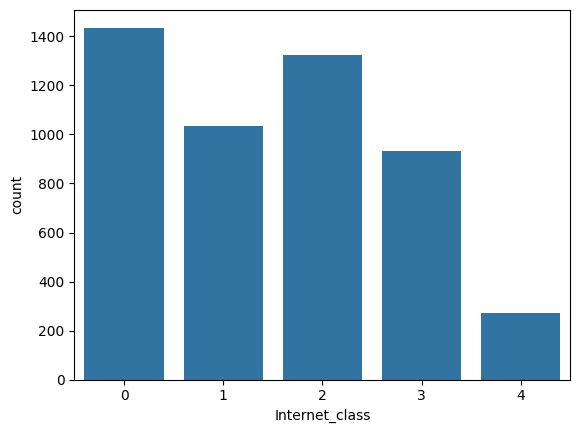

In [37]:
sns.countplot(x='Internet_class', data=df)

In [38]:
df

,Ping_latency,Download_speed,Upload_speed,Packet_loss_rate,Signal_strength,Internet_speed,Total_bandwidth,Upload_download_ratio,Network_efficiency,Signal_reliability,Internet_class
0,21.854305,42.395374,19.934759,0.999340,76.190258,730.336287,62.330134,0.470211,1.939909,38.107695,1
1,47.782144,49.976388,17.979781,1.493494,70.945684,994.148168,67.956168,0.359766,1.045922,28.452323,1
2,37.939727,86.182002,10.455388,1.125334,83.994324,2551.867438,96.637390,0.121318,2.271550,39.520537,3
3,31.939632,37.300417,31.148800,0.166605,92.278904,621.336539,68.449217,0.835079,1.167841,79.100373,1
4,12.020839,87.616720,24.877960,0.371160,80.535702,2612.315499,112.494680,0.283941,7.288736,58.735431,3
...,...,...,...,...,...,...,...,...,...,...,...
4995,45.382879,86.477319,33.242407,1.754077,92.054785,2600.889238,119.719726,0.384406,1.905505,33.424910,3
4996,10.372146,90.263339,10.534320,0.093628,97.745403,2769.740618,100.797660,0.116707,8.702475,89.377202,3
4997,19.752928,94.937252,4.459498,0.607397,97.209409,3031.079831,99.396750,0.046973,4.806237,60.476294,4
4998,41.708542,42.761359,34.782156,0.886640,96.801547,818.064550,77.543516,0.813402,1.025242,51.308965,1


In [39]:
df = df.drop('Internet_speed', axis=1)
df

,Ping_latency,Download_speed,Upload_speed,Packet_loss_rate,Signal_strength,Total_bandwidth,Upload_download_ratio,Network_efficiency,Signal_reliability,Internet_class
0,21.854305,42.395374,19.934759,0.999340,76.190258,62.330134,0.470211,1.939909,38.107695,1
1,47.782144,49.976388,17.979781,1.493494,70.945684,67.956168,0.359766,1.045922,28.452323,1
2,37.939727,86.182002,10.455388,1.125334,83.994324,96.637390,0.121318,2.271550,39.520537,3
3,31.939632,37.300417,31.148800,0.166605,92.278904,68.449217,0.835079,1.167841,79.100373,1
4,12.020839,87.616720,24.877960,0.371160,80.535702,112.494680,0.283941,7.288736,58.735431,3
...,...,...,...,...,...,...,...,...,...,...
4995,45.382879,86.477319,33.242407,1.754077,92.054785,119.719726,0.384406,1.905505,33.424910,3
4996,10.372146,90.263339,10.534320,0.093628,97.745403,100.797660,0.116707,8.702475,89.377202,3
4997,19.752928,94.937252,4.459498,0.607397,97.209409,99.396750,0.046973,4.806237,60.476294,4
4998,41.708542,42.761359,34.782156,0.886640,96.801547,77.543516,0.813402,1.025242,51.308965,1


In [40]:
X = df.drop(columns=['Internet_class'], axis=1)
Y = df['Internet_class']

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)


In [42]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [43]:
lg = LogisticRegression()
print('Logistictic Regression')
lg.fit(X_train_scaled, Y_train)
X_train_prediction = lg.predict(X_train_scaled)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy score of the training data : ', training_data_accuracy)
X_test_prediction = lg.predict(X_test_scaled)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy score of the test data : ', test_data_accuracy)


svm = svm.SVC()
print('Support Vector Machine')
svm.fit(X_train_scaled, Y_train)
X_train_prediction = svm.predict(X_train_scaled)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy score of the training data : ', training_data_accuracy)
X_test_prediction = svm.predict(X_test_scaled)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy score of the test data : ', test_data_accuracy)

rf = RandomForestClassifier()
print('Random Forest Classifier')
rf.fit(X_train_scaled, Y_train)
X_train_prediction = rf.predict(X_train_scaled)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy score of the training data : ', training_data_accuracy)
X_test_prediction = rf.predict(X_test_scaled)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy score of the test data : ', test_data_accuracy)


Logistictic Regression
Accuracy score of the training data :  0.9725
Accuracy score of the test data :  0.969
Support Vector Machine
Accuracy score of the training data :  0.96125
Accuracy score of the test data :  0.94
Random Forest Classifier
Accuracy score of the training data :  1.0
Accuracy score of the test data :  0.976


In [44]:
df.columns

Index(['Ping_latency', 'Download_speed', 'Upload_speed', 'Packet_loss_rate',
       'Signal_strength', 'Total_bandwidth', 'Upload_download_ratio',
       'Network_efficiency', 'Signal_reliability', 'Internet_class'],
      dtype='object')

In [45]:
import numpy as np

print('Enter ping latency : ')
ping_latency = float(input())

print('Enter download speed : ')
download_speed = float(input())

print('Enter upload speed : ')
upload_speed = float(input())

print('Enter signal strength : ')
signal_strength = float(input())

print('Enter packet loss rate : ')
packet_loss_rate = float(input())

# Derived features
bandwidth = download_speed + upload_speed
upload_download_ratio = upload_speed / download_speed
network_efficiency = download_speed / ping_latency
signal_reliability = signal_strength / (packet_loss_rate + 1)

# Create input array (same order as training data)
input_data = np.array([[
    ping_latency,
    download_speed,
    upload_speed,
    packet_loss_rate,
    signal_strength,
    bandwidth,
    upload_download_ratio,
    network_efficiency,
    signal_reliability
]])

# Scale the data
input_scaled = sc.transform(input_data)

# Predictions
lg_pred = lg.predict(input_scaled)
svm_pred = svm.predict(input_scaled)
rf_pred = rf.predict(input_scaled)
print("Logistic Regression Prediction:", lg_pred[0])
print("SVM Prediction:", svm_pred[0])
print("Random Forest Prediction:", rf_pred[0])



predictions = [lg_pred[0], svm_pred[0], rf_pred[0]]
final_prediction = Counter(predictions).most_common(1)[0][0]
print("Final Prediction : " , final_prediction)

Enter ping latency : 
22.82
Enter download speed : 
78.55
Enter upload speed : 
20.43
Enter signal strength : 
90
Enter packet loss rate : 
0
Logistic Regression Prediction: 3
SVM Prediction: 3
Random Forest Prediction: 3
Final Prediction :  3
